<a href="https://colab.research.google.com/github/bhavikd-ai/rag_notes/blob/main/Reciprocal_Rank_Fusion_in_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# INSTALLING REQUIRE LIBRARIES

!pip install rank-bm25 sentence-transformers scikit-learn

In [ ]:
# IMPORTING LIBRARIES

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

In [ ]:
# SAMPLE DOCUMENT

documents = [
    "RAG combines retrieval and generation for question answering.",
    "Vector databases store embeddings for semantic search.",
    "BM25 is a keyword based ranking algorithm.",
    "Reciprocal Rank Fusion combines multiple retrievers.",
    "LangChain helps build LLM applications.",
    "Dense retrieval uses embedding similarity.",
    "Sparse retrieval works well for exact keywords.",
    "FAISS is used for vector similarity search.",
]


In [ ]:
# USER QUERY

query = "How to combine keyword and vector search in RAG?"

In [ ]:
# BM25 RETRIEVER

tokenized_docs = [doc.lower().split() for doc in documents]

bm25 = BM25Okapi(tokenized_docs)

tokenized_query = query.lower().split()

bm25_scores = bm25.get_scores(tokenized_query)

# Rank documents
bm25_ranked = sorted(
    list(enumerate(bm25_scores)),
    key=lambda x: x[1],
    reverse=True
)

print("\n================ BM25 RESULTS ================\n")

for rank, (doc_id, score) in enumerate(bm25_ranked[:8], start=1):
    print(f"Rank {rank}")
    print(f"Score : {score:.4f}")
    print(f"Doc   : {documents[doc_id]}")
    print()

In [ ]:
# DENSE VECTOR RETRIEVER

model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = model.encode(documents)

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

dense_ranked = sorted(
    list(enumerate(similarities)),
    key=lambda x: x[1],
    reverse=True
)

print("\n================ DENSE RETRIEVAL RESULTS ================\n")

for rank, (doc_id, score) in enumerate(dense_ranked[:8], start=1):
    print(f"Rank {rank}")
    print(f"Score : {score:.4f}")
    print(f"Doc   : {documents[doc_id]}")
    print()

In [ ]:
# RECIPROCAL RANK FUSION

def reciprocal_rank_fusion(rankings, k=60):
    """
    rankings:
        List of ranked lists
        Example:
        [
            [(doc_id, score), ...],   # BM25 ranking
            [(doc_id, score), ...]    # Dense ranking
        ]
    """

    rrf_scores = {}

    for ranking in rankings:

        for rank, (doc_id, _) in enumerate(ranking, start=1):

            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0

            rrf_scores[doc_id] += 1 / (k + rank)

    return sorted(
        rrf_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

# Combine BM25 + Dense retrieval
fused_results = reciprocal_rank_fusion(
    [bm25_ranked, dense_ranked]
)


# ---------------------------------------------------
# STEP 6: Final Fused Ranking
# ---------------------------------------------------

print("\n================ RRF FUSED RESULTS ================\n")

for rank, (doc_id, score) in enumerate(fused_results[:8], start=1):
    print(f"Final Rank : {rank}")
    print(f"RRF Score  : {score:.6f}")
    print(f"Document   : {documents[doc_id]}")
    print()

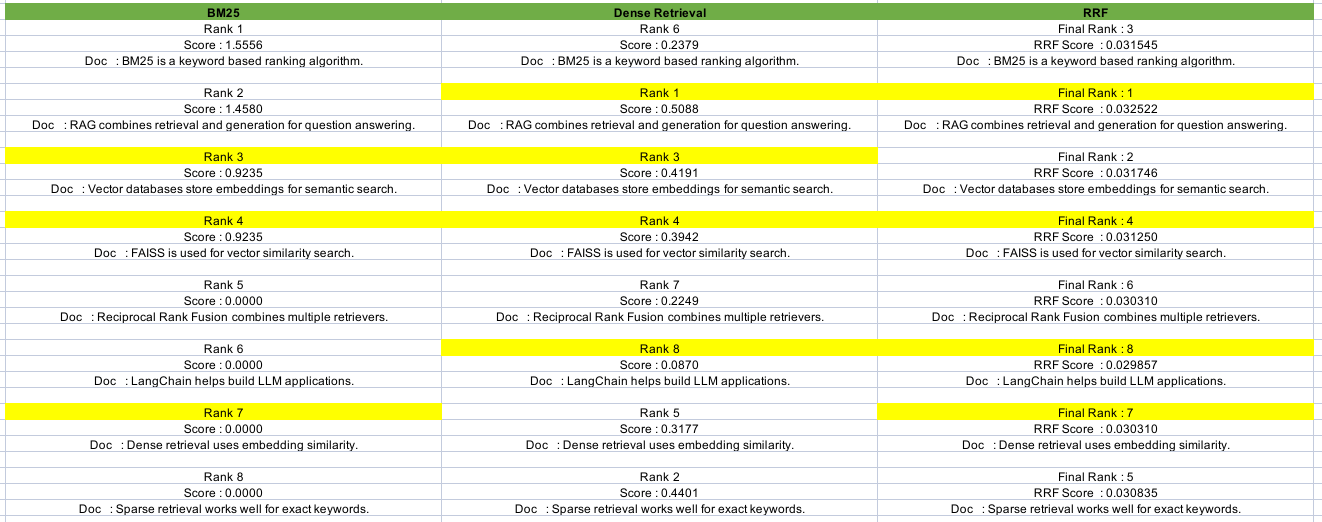

In [ ]:
# AUDIT OF BM25, DENSE & RRF

df = pd.DataFrame()
df["documents"] = documents
df["user_query"] = query
df["bm25_scores"] = bm25_scores
df["bm25_rank"] = df["bm25_scores"].rank(ascending=False, method="first")
df["dense_scores"] = similarities
df["dense_rank"] = df["dense_scores"].rank(ascending=False, method="first")
df["rrf"] = df["rrf"] = (1 / (60 + df["bm25_rank"]) + 1 / (60 + df["dense_rank"]))
df["rrf_rank"] = df["rrf"].rank(ascending=False, method="first")
df = df.sort_values("rrf_rank", ascending=True)
df

### Overall Interpretation

The final RRF ranking shows that documents performing reasonably well across both retrieval methods are ranked higher than documents that perform extremely well in only one retriever.

This helps create a more balanced and robust retrieval system.

In [34]:
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/Reciprocal_Rank_Fusion_in_RAG.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb, f)

print("Cleaned successfully")

Cleaned successfully
